sms spam detection

In [1]:
import numpy as np
import pandas as pd


In [2]:
df=pd.read_csv('spam.csv',encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)

In [4]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)


In [5]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['target']=encoder.fit_transform(df['target'])

In [6]:
df=df.drop_duplicates(keep='first')

In [7]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [8]:
#eda
#Exploratory data analysis

In [9]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x1c8c09bb9b0>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

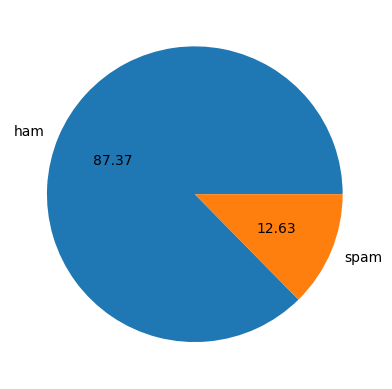

In [10]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")

In [11]:
#data is imbalanced


In [12]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\thele\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\thele\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
df['num_characters']=df['text'].apply(len)

In [15]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [16]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [17]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [18]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [19]:
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()    

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [20]:
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

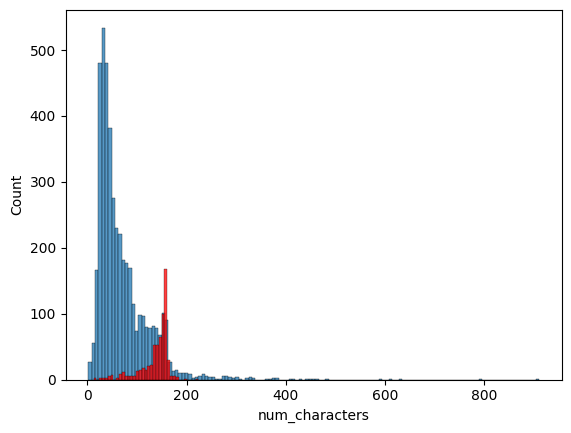

In [21]:
import seaborn as sns
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

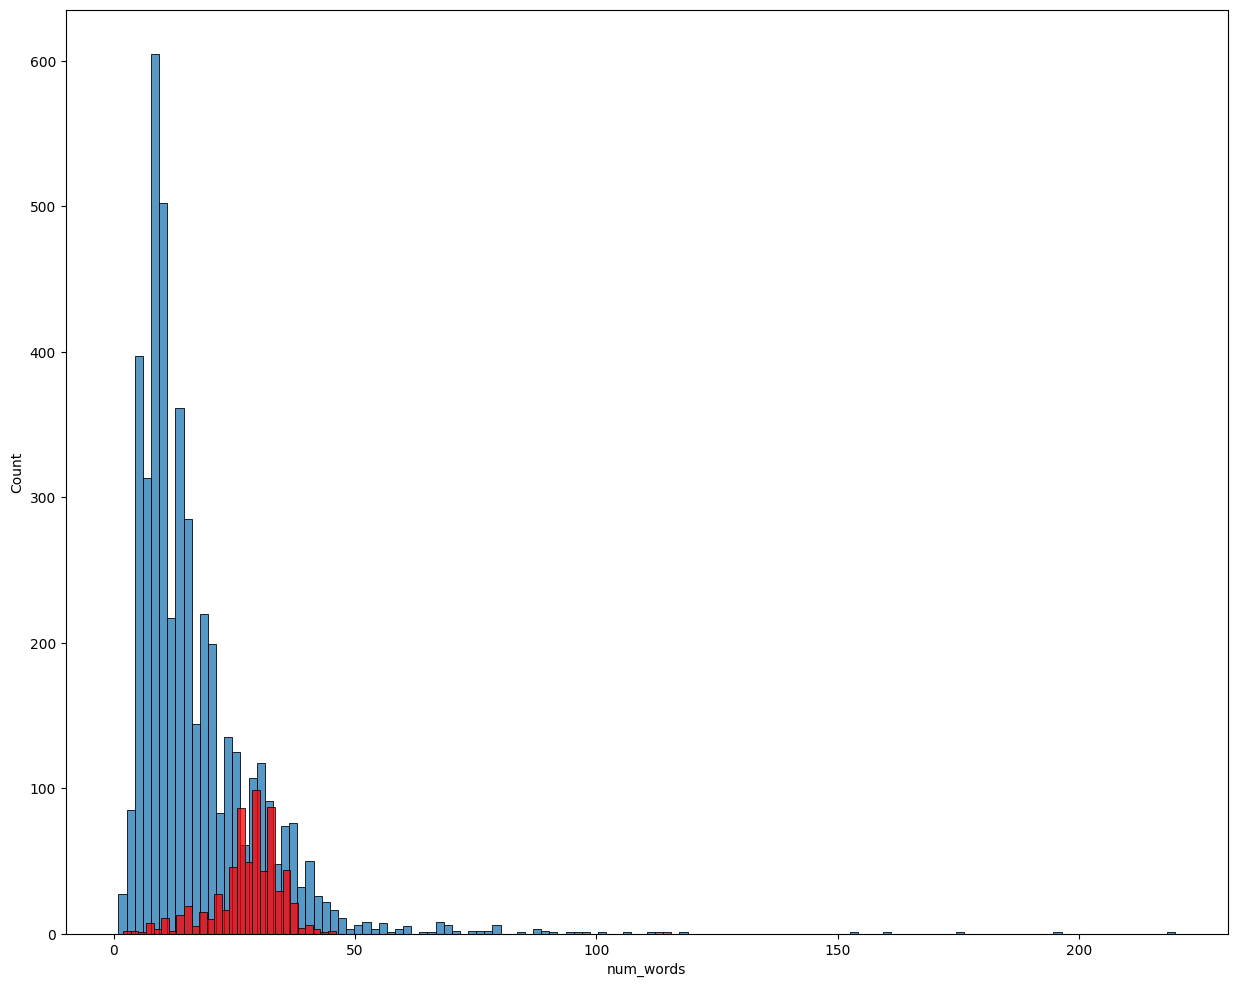

In [22]:
plt.figure(figsize=(15,12))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

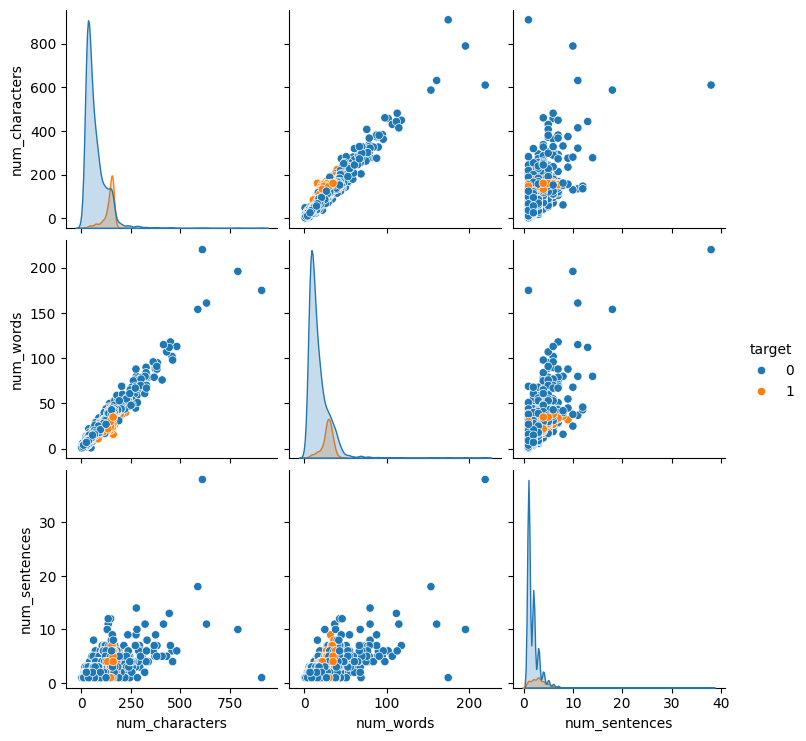

In [23]:
sns.pairplot(df,hue='target')

In [24]:
#data preprocessing
# 1. lower case
# 2. tokenization
# 3. removing special characters
# 4. removing stop words and punctuation
# 5. stemming
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
stopwords.words('english')
ps=PorterStemmer()


In [25]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [26]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)


In [27]:
transform_text('Hello dancing Nice to meet you  aditya you are a loving boy')

'hello danc nice meet aditya love boy'

In [28]:
df['transformed_text']=df['text'].apply(transform_text)

In [29]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [30]:

%pip install wordcloud


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from wordcloud import WordCloud
wc=WordCloud(width=700,height=700,min_font_size=10,background_color='white')

In [32]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

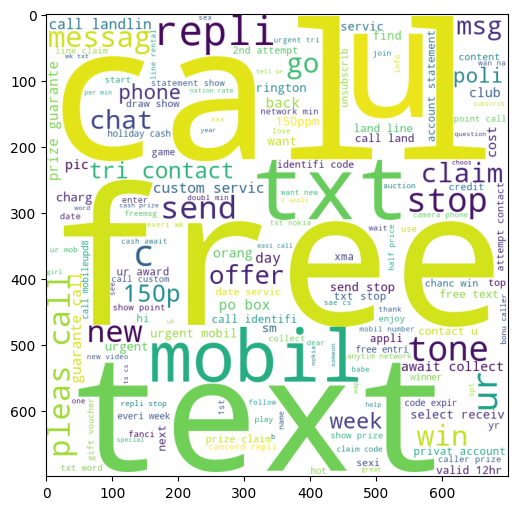

In [33]:
plt.figure(figsize=(10,6))
plt.imshow(spam_wc)

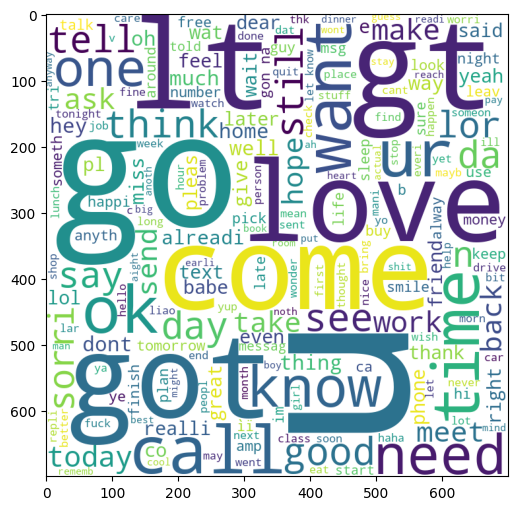

In [34]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10,6))
plt.imshow(ham_wc)

In [35]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for words in msg.split():
        spam_corpus.append(words)

In [36]:
from collections import Counter


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'call'),
  Text(1, 0, 'free'),
  Text(2, 0, '2'),
  Text(3, 0, 'txt'),
  Text(4, 0, 'text'),
  Text(5, 0, 'u'),
  Text(6, 0, 'ur'),
  Text(7, 0, 'mobil'),
  Text(8, 0, 'stop'),
  Text(9, 0, 'repli'),
  Text(10, 0, 'claim'),
  Text(11, 0, '4'),
  Text(12, 0, 'prize'),
  Text(13, 0, 'get'),
  Text(14, 0, 'new'),
  Text(15, 0, 'servic'),
  Text(16, 0, 'tone'),
  Text(17, 0, 'send'),
  Text(18, 0, 'urgent'),
  Text(19, 0, 'nokia'),
  Text(20, 0, 'contact'),
  Text(21, 0, 'award'),
  Text(22, 0, 'phone'),
  Text(23, 0, 'cash'),
  Text(24, 0, 'pleas'),
  Text(25, 0, 'week'),
  Text(26, 0, 'win'),
  Text(27, 0, 'c'),
  Text(28, 0, 'collect'),
  Text(29, 0, 'min')])

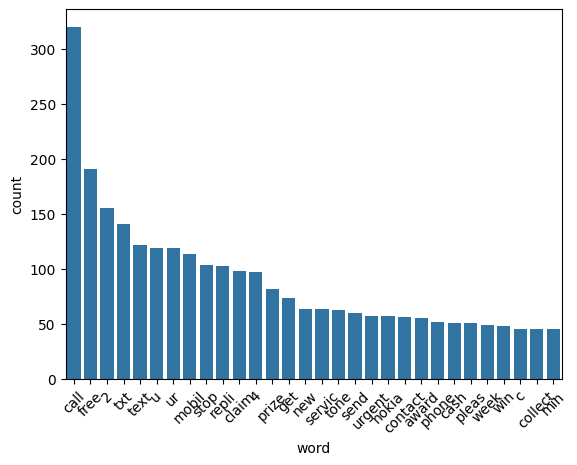

In [37]:
top_30 = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=top_30, x='word', y='count')
plt.xticks(rotation=45)


model building

In [38]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
X=cv.fit_transform(df['transformed_text']).toarray()
X.shape

(5169, 6708)

In [39]:
from sklearn.model_selection import train_test_split
y=df['target'].values
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)


In [40]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()


In [41]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score

In [42]:
gnb.fit(x_train,y_train)
y_pred_gnb=gnb.predict(x_test)

In [43]:
print("GaussianNB Accuracy:",accuracy_score(y_test,y_pred_gnb))
print("GaussianNB Confusion Matrix:\n",confusion_matrix(y_test,y_pred_gnb))
print(precision_score(y_test,y_pred_gnb))

GaussianNB Accuracy: 0.8800773694390716
GaussianNB Confusion Matrix:
 [[792 104]
 [ 20 118]]
0.5315315315315315


In [44]:
mnb.fit(x_train,y_train)
y_pred_mnb=mnb.predict(x_test)
print("MultinomialNB Accuracy:",accuracy_score(y_test,y_pred_mnb))
print("MultinomialNB Confusion Matrix:\n",confusion_matrix(y_test,y_pred_mnb))
print(precision_score(y_test,y_pred_mnb))


MultinomialNB Accuracy: 0.9642166344294004
MultinomialNB Confusion Matrix:
 [[871  25]
 [ 12 126]]
0.8344370860927153


In [45]:
bnb.fit(x_train,y_train)
y_pred_bnb=bnb.predict(x_test)
print(accuracy_score(y_test,y_pred_bnb))
print(precision_score(y_test,y_pred_bnb))


0.9700193423597679
0.9734513274336283


Tf-idf use

In [65]:
tfidf=TfidfVectorizer(max_features=3000)

x1=tfidf.fit_transform(df['transformed_text']).toarray()
y1=df['target'].values


In [47]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,test_size=0.2,random_state=2)

In [48]:
gnb.fit(x1_train,y1_train)
y_pred_gnb=gnb.predict(x1_test)
print("GaussianNB Accuracy:",accuracy_score(y1_test,y_pred_gnb))
print("GaussianNB Confusion Matrix:\n",confusion_matrix(y1_test,y_pred_gnb))
print(precision_score(y1_test,y_pred_gnb))

GaussianNB Accuracy: 0.8762088974854932
GaussianNB Confusion Matrix:
 [[793 103]
 [ 25 113]]
0.5231481481481481


In [ ]:
from sklearn.metrics import accuracy_score as sk_accuracy_score

mnb.fit(x1_train,y1_train)
y_pred_mnb=mnb.predict(x1_test)
print("MultinomialNB Accuracy:", sk_accuracy_score(y1_test, y_pred_mnb))
print("MultinomialNB Confusion Matrix:\n",confusion_matrix(y1_test,y_pred_mnb))
print(precision_score(y1_test,y_pred_mnb))

TypeError: 'list' object is not callable

In [67]:
bnb.fit(x1_train,y1_train)
y_pred_bnb=bnb.predict(x1_test)
print(accuracy_score(y1_test,y_pred_bnb))
print(precision_score(y1_test,y_pred_bnb))


TypeError: 'list' object is not callable

other models

In [51]:
  from sklearn.linear_model import LogisticRegression
  from sklearn.svm import SVC
  from sklearn.tree import DecisionTreeClassifier
  from sklearn.ensemble import RandomForestClassifier
  from sklearn.ensemble import GradientBoostingClassifier
  from sklearn.ensemble import AdaBoostClassifier
  from xgboost import XGBClassifier
  from sklearn.neighbors import KNeighborsClassifier
  from sklearn.ensemble import ExtraTreesClassifier
  from sklearn.ensemble import BaggingClassifier
  from sklearn.naive_bayes import MultinomialNB

In [52]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
dtc=DecisionTreeClassifier()
rfc=RandomForestClassifier()
gbc=GradientBoostingClassifier(n_estimators=50,random_state=2)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
xgbc=XGBClassifier(n_estimators=50,random_state=2)
mnb=MultinomialNB()


In [53]:
cls={
    'svc':svc,
    'KN':knc,
    'dtc':dtc,
    'rfc':rfc,
    'gbc':gbc,
    'lrc':lrc,
    'abc':abc,
    'bc':bc,
    'etc':etc,
    'xgbc':xgbc,
    'mnb':mnb     
    }

In [54]:
def train_classifier(clf,x1_train,y1_train,x1_test,y1_test):
    clf.fit(x1_train,y1_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y1_test,y_pred)
    precision=precision_score(y1_test,y_pred)
    return accuracy,precision
    

In [55]:
from sklearn.metrics import accuracy_score as sk_accuracy_score, precision_score as sk_precision_score
accuracy_score=[]
precision_score=[]
for name,clf in cls.items():
    clf.fit(x1_train, y1_train)
    y_pred = clf.predict(x1_test)
    current_accuracy = sk_accuracy_score(y1_test, y_pred)
    current_precision = sk_precision_score(y1_test, y_pred)
    print("For ",name)
    print("Accuracy is ",current_accuracy)
    print("Precision is ",current_precision)
    accuracy_score.append(current_accuracy)


For  svc
Accuracy is  0.9729206963249516
Precision is  0.9741379310344828
For  KN
Accuracy is  0.9003868471953579
Precision is  1.0
For  dtc
Accuracy is  0.9535783365570599
Precision is  0.8125
For  rfc
Accuracy is  0.9729206963249516
Precision is  0.9824561403508771
For  gbc
Accuracy is  0.9526112185686654
Precision is  0.9238095238095239
For  lrc
Accuracy is  0.9516441005802708
Precision is  0.94
For  abc
Accuracy is  0.9245647969052224
Precision is  0.8409090909090909
For  bc
Accuracy is  0.9584139264990329
Precision is  0.8625954198473282
For  etc
Accuracy is  0.9729206963249516
Precision is  0.9824561403508771
For  xgbc
Accuracy is  0.9748549323017408
Precision is  0.9516129032258065
For  mnb
Accuracy is  0.9593810444874274
Precision is  1.0


In [57]:
import pandas as pd


In [59]:
model_names = list(cls.keys())

# Rebuild metrics safely if any list has wrong length
if len(accuracy_score) != len(model_names) or len(precision_score) != len(model_names):
    accuracy_vals, precision_vals = [], []
    for model in cls.values():
        y_pred = model.predict(x1_test)
        accuracy_vals.append(sk_accuracy_score(y1_test, y_pred))
        precision_vals.append(sk_precision_score(y1_test, y_pred))
else:
    accuracy_vals = accuracy_score
    precision_vals = precision_score

performance_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_vals,
    'Precision': precision_vals
})
performance_df.sort_values(by='Precision',ascending=False,inplace=True)

In [60]:
performance_df

,Model,Accuracy,Precision
1,KN,0.900387,1.000000
10,mnb,0.959381,1.000000
3,rfc,0.972921,0.982456
8,etc,0.972921,0.982456
0,svc,0.972921,0.974138
9,xgbc,0.974855,0.951613
5,lrc,0.951644,0.940000
4,gbc,0.952611,0.923810
7,bc,0.958414,0.862595
6,abc,0.924565,0.840909


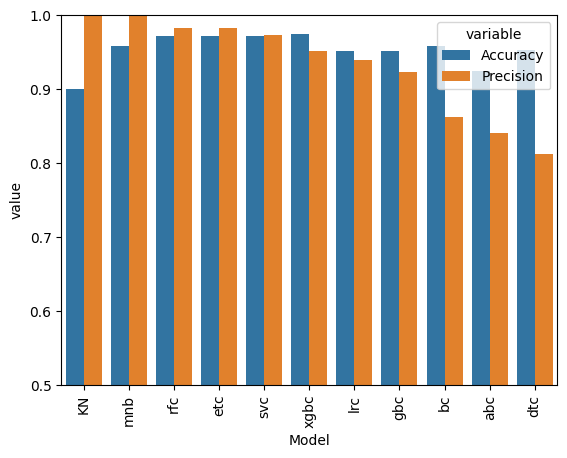

In [64]:
plot_df = performance_df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision'],
    var_name='variable',
    value_name='value'
)
sns.barplot(x='Model', y='value', hue='variable', data=plot_df)
plt.xticks(rotation='vertical')
plt.ylim(0.5,1.0)
plt.show()


In [ ]:
import pickle 
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(cls['mnb'],open('model.pkl','wb'))
